# Importation du Drive et instalations nécessaires :

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! pip install pydot graphviz

# Importation des bibliotheques nécessaires

---



In [ ]:
#les import

import numpy as np

import random

import matplotlib.pyplot as plt
from tensorflow import keras


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Input, Dropout, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score, classification_report, accuracy_score


import seaborn as sns

import tensorflow as tf
from tensorflow.keras.utils import Sequence

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


# Chargement du dataset depuis Google Drive

---



In [ ]:

#paths du drive  :

x_train_p = "/content/drive/MyDrive/Colab Notebooks/seg_aug/X_train_augmented.npy"
y_train_p = "/content/drive/MyDrive/Colab Notebooks/seg_aug/y_train_augmented.npy"
x_test_p = "/content/drive/MyDrive/Colab Notebooks/seg_aug/X_test.npy"
y_test_p = "/content/drive/MyDrive/Colab Notebooks/seg_aug/y_test.npy"

#loading
x_train= np.load(x_train_p)
y_train= np.load(y_train_p)
x_test= np.load(x_test_p)
y_test= np.load(y_test_p)


# Chargement du dataset DISC

---



In [ ]:
import os
#paths :
processed_path=r'C:\Users\esp\Desktop\PFE\ines\data_proc\train_test_sets'

x_train_p = os.path.join(processed_path, 'X_train_augmented.npy')
y_train_p = os.path.join(processed_path, 'y_train_augmented.npy')
x_test_p = os.path.join(processed_path, 'X_test.npy')
y_test_p = os.path.join(processed_path, 'y_test.npy')

#loading
x_train= np.load(x_train_p)
y_train= np.load(y_train_p)
x_test= np.load(x_test_p)
y_test= np.load(y_test_p)

# Vérification de la forme du dataset


---


1. Vérification du bon chargement des données et de leurs dimensions :

- `x_train` : signaux ECG  
- `y_train` : labels (classes)  
- 360 : nombre d'échantillons correspondant à 1 seconde de signal (360 Hz)  
- 332 890 : nombre total de segments extraits

2. Reshape : ajout d'une 3ᵉ dimension au tenseur d'entrée pour préciser le nombre de dérivations (ici 1 seule dérivation, Lead I).

In [ ]:
#verifier shape input/loading:
print(np.shape(x_train),np.shape(y_train) , np.shape(x_test) , np.shape(y_test))

x_train = x_train.reshape(-1, 360, 1)
x_test = x_test.reshape(-1, 360, 1)

print(np.shape(x_train),np.shape(y_train) , np.shape(x_test) , np.shape(y_test))

(332890, 360, 1) (332890,) (20399, 360, 1) (20399,)


# Encodage des données

---



Les CNN ne traitent que des données numériques, donc il faut convertir les étiquettes (y_train et y_test)
 en entiers. Par exemple :                                                   
   [ 0, 1, 2, 3, 4 ] == [ F, N, Q, S, V ]

 Cela permet aussi d'utiliser la fonction de perte 'sparse_categorical_crossentropy',
 qui nécessite des labels sous forme d'entiers.


In [ ]:
# creer un encodeur
coder = LabelEncoder()

# Encoder les labels de lettres en entiers
y_train_encoded = coder.fit_transform(y_train)
y_test_encoded = coder.transform(y_test)


# Conception du modele CNN

---



In [ ]:
# Architecture du modele 

model = Sequential()
model.add(Input(shape=(360, 1)))  # def la forme de l'entrée ici, 360 échantillons, 1 canal (ECG 1D)

model.add(Conv1D(48, 3, activation='relu', kernel_regularizer=l2(1.1875e-05) ))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.2))

model.add(Conv1D(64, 5, activation='relu', kernel_regularizer=l2(0.0006214) ))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.2))

model.add(Conv1D(64, 3, activation='relu', kernel_regularizer=l2(1e-05) ))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.2))  

model.add(Flatten())
model.add(Dense(96, activation='relu', kernel_regularizer=l2(1.1875e-05) ))
model.add(Dropout(0.2))  

model.add(Dense(5, activation='softmax'))


# Optimisation et Entraînement du modèle:

In [ ]:
# Calculer les poids par classe
# y_train contient les labels entiers (0, 1, 2, 3, 4)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))


# Compile avec Adam + lr 
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    verbose=1,
    mode='max',
    min_lr=1e-5
)


# Entrainement avec class weights
courbe = model.fit(
    x_train, y_train_encoded,
    epochs=40,
    validation_data=(x_test, y_test_encoded),
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

# Visualisation des courbes Accuracy et Loss :

---



In [ ]:
# la courbe de perte - Loss
plt.plot(courbe.history['loss'], label='Loss (train)')
plt.plot(courbe.history['val_loss'], label='Loss (val)')
plt.title('Loss pendant l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# la courbe de precision - Accuracy
plt.plot(courbe.history['accuracy'], label='Accuracy (train)')
plt.plot(courbe.history['val_accuracy'], label='Accuracy (val)')
plt.title('Accuracy pendant l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Saving du model et visualisation de l'Architecture :

---



In [ ]:
# Sauvegarde du modele (architecture + poids + optimizer)
save_path = "/content/drive/MyDrive/ECG_Model/ecg1/ecg.keras"
model.save(save_path)

# Loading et affichage :
cnn_model = keras.models.load_model('save_path')
cnn_model.summary()

# Prédiction et  évaluation des performances du modele

---



In [ ]:
# Convertir les predictions en labels (indice de la prob max)
y_train_pred = np.argmax(model.predict(x_train), axis=1)
y_test_pred = np.argmax(model.predict(x_test), axis=1)


# Calcul de l'accuracy globale
acc_trainAV= accuracy_score(y_train_encoded, y_train_pred)
acc_testAV= accuracy_score(y_test_encoded, y_test_pred)


# Calcul du F1-score global
f1_trainAV = f1_score(y_train_encoded, y_train_pred, average='macro')
f1_testAV = f1_score(y_test_encoded, y_test_pred, average='macro')


# Calcul du Recall global
recall_trainAV = recall_score(y_train_encoded, y_train_pred, average='macro')
recall_testAV = recall_score(y_test_encoded, y_test_pred, average='macro')

print(f'F1-score train : {f1_trainAV:.4f}')
print(f'Sensibilité train : {recall_trainAV:.4f}')
print(f'Accuracy train : {acc_trainAV:.4f}\n')

print(f'F1-score test : {f1_testAV:.4f}')
print(f'Sensibilité test : {recall_testAV:.4f}')
print(f'Accuracy test : {acc_testAV:.4f}')

 # Matrice de confusion :

---



In [ ]:
# Calcul de la matrice
confusion_train = confusion_matrix(y_train_encoded, y_train_pred)
confusion_test = confusion_matrix(y_test_encoded, y_test_pred)


# Normalisation en %
confusion_train_normalized = confusion_train.astype('float') / confusion_train.sum(axis=1).reshape(-1, 1)
confusion_test_normalized = confusion_test.astype('float') / confusion_test.sum(axis=1).reshape(-1, 1)

# L'entrainement
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_train_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=True)
plt.title('Matrice de confusion normalisée (Entraînement)')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.show()

# Le test
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_test_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=True)
plt.title('Matrice de confusion normalisée (Test)')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.show()


# Rapport de classification

---



In [ ]:
# Entrainement
print( "Rapport de classification - Entraînement")
print(classification_report(y_train_encoded, y_train_pred, target_names=coder.classes_))

# Test
print(" Rapport de classification - Test")
print(classification_report(y_test_encoded, y_test_pred, target_names=coder.classes_))


# Prédiction aléatoire : test d’un échantillon du jeu de test

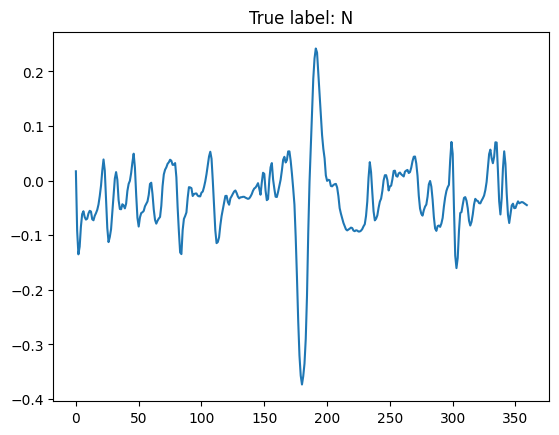

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Our model says it is a: 1


In [ ]:
# Sélectionner un échantillon aléatoire du test
j = random.randint(0, len(x_test) - 1)

# Afficher l'ECG
plt.plot(x_test[j])
plt.title(f"True label: {y_test[j]}")
plt.show()

# Prédire la classe de l'échantillon sélectionné
y_pred = model.predict(x_test[j].reshape(1, 360, 1))
y_pred_label = np.argmax(y_pred, axis=1)

# Afficher la prédiction
print(f"Our model says it is a: {y_pred_label[0]}")

# DIAGNOSTIQUE PATIENT :

In [ ]:

#from collections import Counter

# === Fonction de classification globale AAMI ===
def classer_ecg_global(classe_counts):
    total = sum(classe_counts.values())
    if total == 0:
        return 'Inconnu'

    pourcentages = {k: (v / total) * 100 for k, v in classe_counts.items()}

    if pourcentages.get('Q', 0) > 20:
        return 'Q'
    if pourcentages.get('V', 0) >= 20:
        return 'V'
    if pourcentages.get('S', 0) >= 5:
        return 'S'
    if pourcentages.get('F', 0) >= 1:
        return 'F'
    if pourcentages.get('N', 0) >= 80:
        return 'N'

    return 'Inconnu'

# === Mapping des labels numériques à AAMI ===
id2label = {0: 'F', 1: 'N', 2: 'Q', 3: 'S', 4: 'V'}

# === Fonction pour prédire et classer un patient ===
def predire_patient_numpy(x_path):
    patient_id = os.path.basename(x_path).replace("x_", "").replace(".npy", "")
    x_patient = np.load(x_path)  # shape: (nb_segments, 360)

    # S'assurer que le modele attend (nb_segments, 360, 1)
    if x_patient.ndim == 2:
        x_patient = x_patient[..., np.newaxis]

    # Prédictions
    y_pred = model.predict(x_patient)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_pred_classes = [id2label[i] for i in y_pred_labels]

    # Comptage
    classe_counts = dict(Counter(y_pred_classes))
    classe_globale = classer_ecg_global(classe_counts)

    print(f"--- Patient {patient_id} ---")
    print("Répartition des classes :", classe_counts)
    print("Classe globale :", classe_globale)
    print()


In [ ]:
# === Exemple : appliquer sur un seul patient ===
x_file = "/content/drive/MyDrive/testing_pour_ines/converted_patients/x_106.npy"
predire_patient_numpy(x_file)
